In [118]:
#preserved concepts
!pip install numpy==1.26.4
import numpy as np
print(np.version.version)
!pip install pandas
import concept_getters
import pandas as pd
import re
import os
SPARSITY_RATIOS_LTH = [0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
SPARSITY_RATIOS_WANDA = [0.0, 19.987, 35.97, 48.796, 59.017, 67.22, 73.763, 79.004, 83.203, 86.556, 89.258, 91.406, 93.099, 94.499]
expl_clus=3
import collections

def get_indiv_concepts_per_unit(df) -> dict:
    concepts = {}
    for unit,expl in zip(df.unit, df.best_name):
        concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', expl)
        for i in range(len(concps)):
            while concps[i][-1] == ')':
                concps[i] = concps[i][:-1]
        concepts[unit] = concps
    return concepts

def get_concepts_across_pruning_per_neuron(model, method, filename, sparsity_list):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(dict)
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            reordered[neuron][sparsity] = concepts
    return reordered 

def get_concepts_assoc_sparsities(model, method, filename, sparsity_list):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(lambda: collections.defaultdict(set))
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            for concept in concepts:
                reordered[neuron][concept].add(sparsity)
    return reordered 

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip
1.26.4
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


In [104]:
lth_acc=pd.read_csv("/workspace/CCE_NLI/BERT/models/lottery_ticket/Run2Full/Accuracies/accuracy.csv")
for i,v in enumerate(lth_acc['Unnamed: 0']):
    newkey = int(v.split("_")[0])
    lth_acc['Unnamed: 0'].iloc[i] = newkey
accs = lth_acc.sort_values(by='Unnamed: 0')['0']
lth_acc= list(accs)

wanda_acc=pd.read_csv("/workspace/CCE_NLI/BERT/models/wanda/Run2Full/Accuracies/accuracy.csv")
for i,v in enumerate(wanda_acc['Unnamed: 0']):
    newkey = int(v.split("_")[0])
    wanda_acc['Unnamed: 0'].iloc[i] = newkey
accs = wanda_acc.sort_values(by='Unnamed: 0')['0']
wanda_acc=list(accs)

/tmp/ipykernel_6177/3348075271.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lth_acc['Unnamed: 0'].iloc[i] = newkey
/tmp/ipykernel_6177/3348075271.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wanda_acc['Unnamed: 0'].iloc[i] = newkey


In [105]:
np.version.version

'1.26.4'

In [106]:
def count_frequencies(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
  

unique_concepts =set()
def num_unique_concepts_for_a_neuron(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    for concept in concept_freq:
        unique_concepts.add()
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
                
        
        

In [107]:
list_of_repeated_concepts = set()
reordered = get_indiv_concepts_per_unit(df)
for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    concepts = list(frequencies.keys())
    for c in concepts:
        list_of_repeated_concepts.add(c)


NameError: name 'df' is not defined

In [108]:
len(list_of_repeated_concepts) 
#across all neurons and all iterations, 160 concepts repeat within a neuron at least 5 times 
#(meaning across 1024 neurons there are 106 uniue concepts where across pruning they are dominant 5/14 iterations ) 
#doesnt show whether they're dominant in begining/middle/end just that they're preserved 30% of iters for at least 1 neuron

0

In [109]:
#graph for each neuron on avg how many concepts are repeated % of times
list_of_repeated_concepts = set()
unique = 0
for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    num_u = num_unique_concepts_for_a_neuron(reordered,neuron)
    unique+=len(num_u)
    
    concepts = list(frequencies.keys())
num_u

NameError: name 'reordered' is not defined

# neuron wise: % of concepts preserved for at least first k iters
so for first 1 iters (ie only 1 iter 0.0%), should be 1.0 (all concepts are preserved for at least 1 iter)

'model="BOWMAN"\nbowman_dropoffs_lth = []\nmethod = \'lottery_ticket\'\nfilename = \'Run1\'\nsparsity_list = get_sparsities(model, method, filename)\nfor k in range(1,15):\n    num_orig_cps = get_num_concpets_explained_originally(method, filename)\n    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)\n    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)\n    #print(f"\n\n{concept_assoc_sparsity}")\n    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)\n    bowman_dropoffs_lth.append(percent_of_concepts_preserved)\n    \n    \nbowman_dropoffs_wanda = []\nmethod = \'wanda\'\nfilename = \'Run1\'\n\n\nsparsity_list = get_sparsities(model, method, filename)\nfor k in range(1,15):\n    num_orig_cps = get_num_concpets_explained_originally(method, filename)\n    neuron_

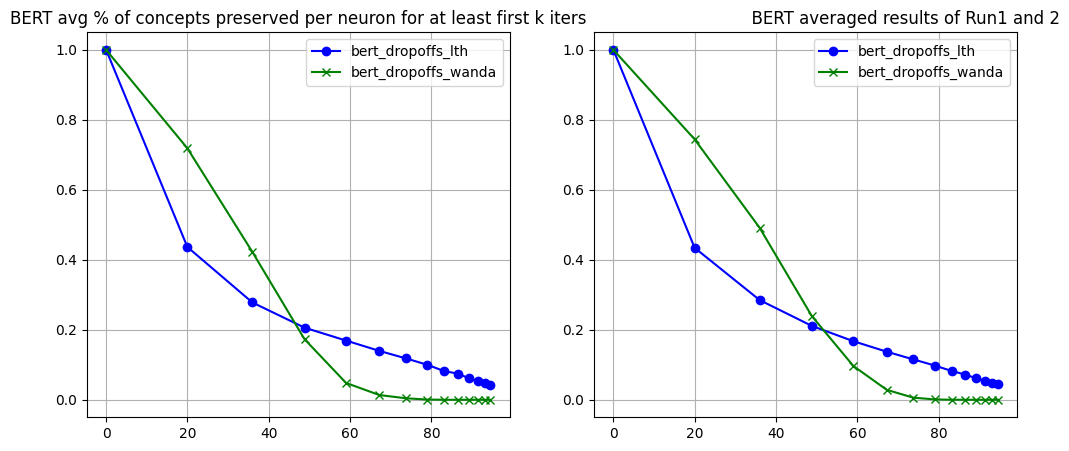

In [119]:
import matplotlib.pyplot as plt

def get_num_concpets_explained_originally(method, filename):
    unique_concepts=set()
    explanations = {}
    if filename == 'Random':
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Expls/Cluster{expl_clus}IOUS1024N.csv")
        
    else:
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
    
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    for neuron, concepts in all_concept_at_original.items():
        for concept in concepts:
            unique_concepts.add(concept)
    return len(unique_concepts) 



def dropoff(method, filename, k, **kwargs):
        
    num_orig_cps = kwargs['num_orig_cps']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    
    percent_cocnepts_preserved=[]
    for neuron in sparsity_mapping.keys():
        concepts_preserved=set()
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                concepts_preserved.add(concept)
        #print(neuron, len(concepts_preserved), len(sparsity_mapping[neuron][0.0]))
        if 0.0 in sparsity_mapping[neuron].keys():
            percent_cocnepts_preserved.append(len(concepts_preserved)/len(sparsity_mapping[neuron][0.0]))
        
    return sum(percent_cocnepts_preserved)/len(percent_cocnepts_preserved)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

def get_sparsities(model, method, filename):
    li=[]
    for s in sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/")):
        if '.ipy' in s: continue
        li.append(float(s.split("%")[0]))
    return li

x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 

model="BERT"
bert_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run3'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename, sparsity_list)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bert_dropoffs_wanda = []
method = 'wanda'
filename = 'Run3'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename, sparsity_list)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda.append(percent_of_concepts_preserved)
    

axs[0].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue',marker='o')
axs[0].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green',marker='x')
axs[0].set_title('BERT avg % of concepts preserved per neuron for at least first k iters')
axs[0].legend()
axs[0].grid(True)


model="BERT"
bert_dropoffs_lth_2 = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename, sparsity_list)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename, sparsity_list)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth_2.append(percent_of_concepts_preserved)
    
    
bert_dropoffs_wanda_2 = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename, sparsity_list)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename, sparsity_list)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda_2.append(percent_of_concepts_preserved)
    
bert_dropoffs_lth = [(x+y)/2 for x,y in zip(bert_dropoffs_lth, bert_dropoffs_lth_2)]
bert_dropoffs_wanda = [(x+y)/2 for x,y in zip(bert_dropoffs_wanda, bert_dropoffs_wanda_2)]


axs[1].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue',marker='o')
axs[1].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green',marker='x')
axs[1].set_title('                                      BERT averaged results of Run1 and 2')
axs[1].legend()
axs[1].grid(True)

    

'''model="BOWMAN"
bowman_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run1'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    #print(f"\n\n{concept_assoc_sparsity}")
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bowman_dropoffs_wanda = []
method = 'wanda'
filename = 'Run1'


sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    #print(f"\n\n{concept_assoc_sparsity}")
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_wanda.append(percent_of_concepts_preserved)
    


axs[1].plot(x, bowman_dropoffs_lth, label='bowman_dropoffs_lth', color='blue',marker='o')
axs[1].plot(x, bowman_dropoffs_wanda, label='bowman_dropoffs_wanda', color='green',marker='x')
axs[1].set_title('                                      BOWMAN avg % of concepts preserved per neuron for at least first k iters')
axs[1].legend()
axs[1].grid(True)'''



#so ex 30% of concepts make it to the 3rd pruning iter staying with the same neuron
    
  

# % of neurons that preserve concepts for at lesat first k iters

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/CCE_NLI/BOWMAN/exp/lottery_ticket/Run1/Expls/'

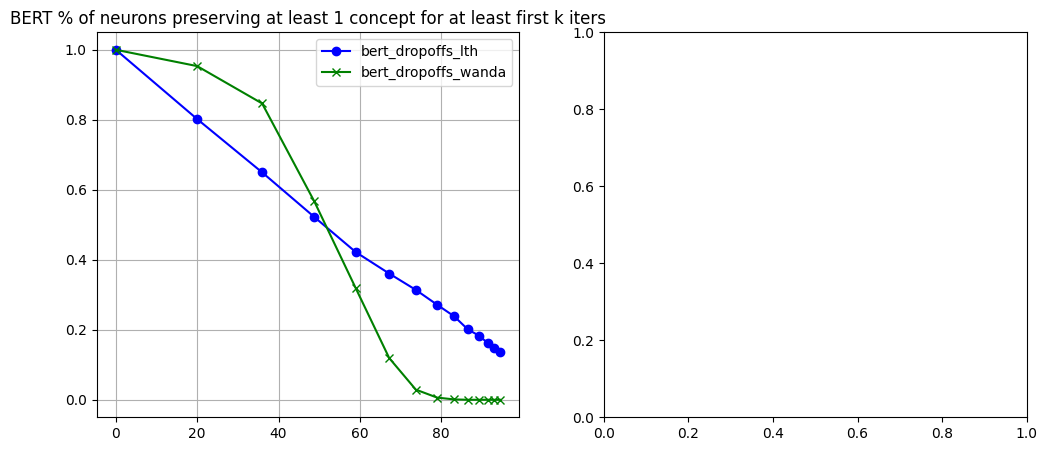

In [122]:
import torch
def get_neurons_explained_originally(model, method, filename):
    unique_concepts=set()
    explanations = {}
    if filename == 'Random':
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/Expls/Cluster{expl_clus}IOUS1024N.csv")
    else:
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
    
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    return len(list(all_concept_at_original.keys()))

def get_sparsity_list(model, method, filename):
    sparsities = []
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        sparsities.append(float(sparsity))
    return sorted(sparsities)
        
def dropoff(method, filename, k, **kwargs):
    sparsity_list = get_sparsity_list(model, method, filename)
    num_orig_neurons = kwargs['num_orig_neurons']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    neurons_preserved = [False for i in range(num_orig_neurons)]
    for i,neuron in enumerate(sparsity_mapping.keys()):
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                neurons_preserved[i] = True
                break
    return torch.where(torch.tensor(neurons_preserved)==1, 1,0).sum()/num_orig_neurons


    
    
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 

model="BERT"
bert_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename,sparsity_list)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth.append(percent_of_concepts_preserved)

    
bert_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = get_sparsities(model, method, filename)
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename,sparsity_list)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda.append(percent_of_concepts_preserved)
    


axs[0].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue',marker='o')
axs[0].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green',marker='x')
axs[0].set_title('BERT % of neurons preserving at least 1 concept for at least first k iters')
axs[0].legend()
axs[0].grid(True)




model="BOWMAN"
bowman_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run1'
sparsity_list_l = get_sparsities(model, method, filename)
for k in range(1,len(sparsity_list_l)+1):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list_l)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename,sparsity_list_l)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bowman_dropoffs_wanda = []
method = 'wanda'
filename = 'Run1'
sparsity_list_w = get_sparsities(model, method, filename)
for k in range(1,len(sparsity_list_w)+1):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename,sparsity_list_w)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename,sparsity_list_w)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_wanda.append(percent_of_concepts_preserved)
    

axs[1].plot(sparsity_list_l, bowman_dropoffs_lth, label='bowman_dropoffs_lth', color='blue',marker='o')
axs[1].plot(sparsity_list_w, bowman_dropoffs_wanda, label='bowman_dropoffs_wanda', color='green',marker='x')
axs[1].set_title('                                       BOWMAN neurons preserving at least 1 concept for at least first k iters')
axs[1].legend()
axs[1].grid(True)



#65% of neurons preserve concepts for at least 3 pruning iters
#shows that for bert more single neurons preserve concepts 

# global overlap: % of concepts that are preserved in kth pruning iter compared to original

425 425
128 512
351 503
122 522
309 531
123 507
283 530
125 478
217 486
106 387
186 477
107 346
155 473
92 326
128 475
92 301
124 466
88 292
118 463
85 286
101 448
79 260
101 454
76 269
98 454
82 260
90 461
77 264
423 423
127 511
308 546
121 525
325 557
132 542
312 550
139 515
302 566
126 534
298 561
128 523
303 546
125 516
300 539
122 509
295 535
121 501
289 544
123 502
275 513
116 464
280 516
109 479
277 523
121 471
281 526
119 480


FileNotFoundError: [Errno 2] No such file or directory: '/workspace/CCE_NLI/BOWMAN/exp/wanda/Run1/Expls/'

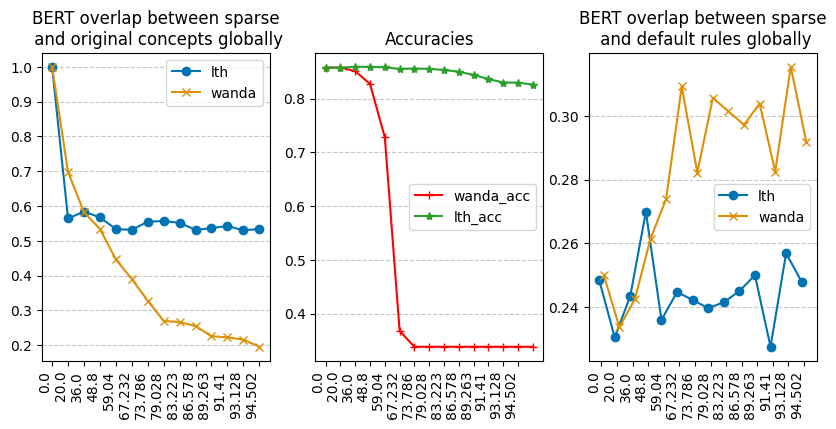

In [124]:
import os
import matplotlib.pyplot as plt
import numpy as np

def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
    return explanations
def overlap(cur, prev):
    intersection = len(cur.intersection(prev))
    union = len(cur.union(prev))
    print(intersection, union)
    return intersection / union if union > 0 else 0



fig, axs = plt.subplots(1, 3, figsize=(10, 4))  # 1 row, 2 columns

pretrained_concepts = set()

for concepts in get_indiv_concepts_per_unit(pd.read_csv("/workspace/CCE_NLI/BERT/exp/PretrainedWeights/Expls/Cluster3IOUS1024N.csv")).values():
    pretrained_concepts.update(concepts)
    
method='wanda'
filename='Run3'
model='BERT'
global_concepts = get_concepts_across_cluster(model,method, filename)
base_concepts = global_concepts[0.0]
bert_overlap_between_sparse_and_pretrained_wanda=[]
bert_overlap_between_sparse_and_base_wanda= []
for sparsity in global_concepts:
    bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
    bert_overlap_between_sparse_and_pretrained_wanda.append(overlap(global_concepts[sparsity], pretrained_concepts))
    
method='lottery_ticket'
filename='Run3'
model='BERT'
global_concepts = get_concepts_across_cluster(model, method, filename)
global_concepts_lth=global_concepts
base_concepts = global_concepts[0.0]

bert_overlap_between_sparse_and_base_lth= []
bert_overlap_between_sparse_and_pretrained_lth = []
for sparsity in global_concepts:
    bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
    bert_overlap_between_sparse_and_pretrained_lth.append(overlap(global_concepts[sparsity], pretrained_concepts))

x=get_sparsities(model, method, filename)
x_pos_l = np.arange(len(x))  # Numeric positions for bars
bar_width = 0.3
# First plot


axs[0].plot(bert_overlap_between_sparse_and_base_lth, label='lth', color='#0173b2',marker='o')
axs[0].plot(bert_overlap_between_sparse_and_base_wanda, label='wanda', color='#de8f05',marker='x')
axs[0].set_title('BERT overlap between sparse\n and original concepts globally')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos_l)
axs[0].set_xticklabels(x, rotation=90, ha='right')

axs[1].plot(wanda_acc, label='wanda_acc', color='#FF0000',marker='+')
axs[1].plot(lth_acc, label='lth_acc', color='#2ca02c',marker='*')
axs[1].legend()
axs[1].set_title('Accuracies')
axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[1].set_xticks(x_pos_l)
axs[1].set_xticklabels(x, rotation=90, ha='right')

# First plot
axs[2].plot(x_pos_l - bar_width/2, bert_overlap_between_sparse_and_pretrained_lth, label='lth', color='#0173b2',marker='o')
axs[2].plot(x_pos_l + bar_width/2, bert_overlap_between_sparse_and_pretrained_wanda, label='wanda', color='#de8f05',marker='x')
axs[2].set_title('BERT overlap between sparse\n and default rules globally')
axs[2].legend()
axs[2].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[2].set_xticks(x_pos_l)
axs[2].set_xticklabels(x, rotation=90, ha='right')

method='wanda'
filename='Run1'
model='BOWMAN'
        
x_w=get_sparsities(model, method, filename)
x_pos_w = np.arange(len(x_w))  # Numeric positions for bars

global_concepts = get_concepts_across_cluster(model,method, filename)
base_concepts = global_concepts[0.0]
bowman_overlap_between_sparse_and_base_wanda= []
for sparsity in global_concepts:
    bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
    
method='lottery_ticket'
filename='Run1'
model='BOWMAN'
global_concepts = get_concepts_across_cluster(model, method, filename)
base_concepts = global_concepts[0.0]
bowman_overlap_between_sparse_and_base_lth= []
for sparsity in global_concepts:
    bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        
x=get_sparsities(model, method, filename)
x_pos_l = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3


# Second plot
axs[2].bar(x_pos_l- bar_width/2, bowman_overlap_between_sparse_and_base_lth, label='lth',color='#0173b2', width=bar_width)
axs[2].bar(x_pos_w+bar_width/2, bowman_overlap_between_sparse_and_base_wanda, label='wanda',color='#de8f05', width=bar_width)
axs[2].set_title('BOWMAN overlap between sparse\n and original concepts globally')
axs[2].set_xticks(x_pos_w)
axs[2].legend()

plt.tight_layout()
plt.show()


67 is where wanda acc drops down to 33% and thats where the overlap with the default starts losing consistency 
as acc drops the wanda alignemnt w default increases then when the acc plateaus staying around 33 the alignment with default rules fluctuates

lottery consistently has lower alginment with default 

this is global alignment what about neuron wise alignemnt (do next cl


In [123]:
df=pd.read_csv("/workspace/CCE_NLI/BERT/exp/PretrainedWeights/Expls/Cluster3IOUS1024N.csv")
default_cps_per_neuron = get_indiv_concepts_per_unit(df)


In [102]:
len(global_concepts_lth[91.41]), len(pretrained_concepts)

(373, 215)

"model='BOWMAN'\nmethod='lottery_ticket'\nfilename='Run1'\nx=get_sparsities(model, method, filename)\nx_axis=get_sparsities(model, method, filename)        \nx_pos = np.arange(len(x_axis))  # Numeric positions for bars\n# Plot grouped bars with offsets\naxs[1].bar(x_pos - bar_width/2, get_num_concepts_across_cluster(model, method, filename), \n           label='lth', color='#0173b2', width=bar_width)\n\n        \nmodel='BOWMAN'        \nmethod='wanda'\nfilename='Run1'\nx_axis=get_sparsities(model, method, filename)        \nx_pos = np.arange(len(x_axis))  # Numeric positions for bars\naxs[1].bar(x_pos + bar_width/2, get_num_concepts_across_cluster(model, method, filename), \n           label='wanda',color='#de8f05', width=bar_width)\n\naxs[1].set_title('BOWMAN number of unique concepts across cluster')\naxs[1].legend()\naxs[1].grid(True, axis='y', linestyle='--', alpha=0.7)\naxs[1].set_xticks(x_pos)\naxs[1].set_xticklabels(x_axis, rotation=90, ha='right')"

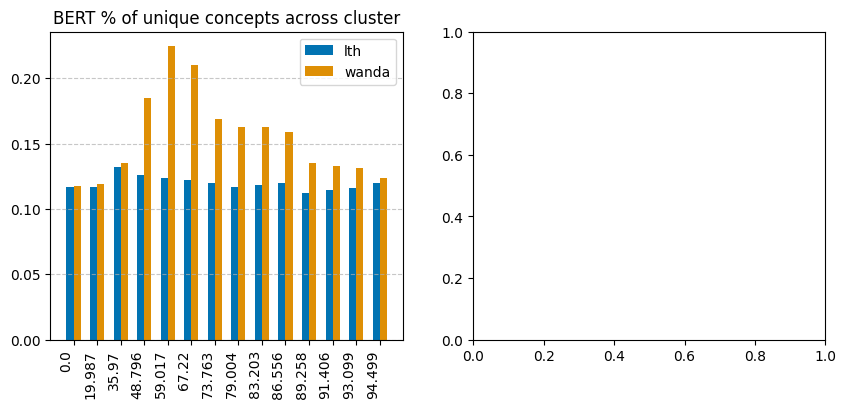

In [18]:
def get_number_of_unique_concepts_global(df):
    concepts=set()
    total = []
    for neuron,expls in get_indiv_concepts_per_unit(df).items():
        concepts.update(expls)
        total.extend(expls)
    return len(concepts), len(total)

def get_num_concepts_across_cluster(model, method, filename):
    explanations = []
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        num_unique, total = get_number_of_unique_concepts_global(cluster3_expls)
        explanations.append(num_unique/total)
    return explanations
import numpy as np

fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns


bar_width = 0.3

model='BERT'
method='lottery_ticket'
filename='Run3'
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='lth', color='#0173b2', width=bar_width)

        
model='BERT'        
method='wanda'
filename='Run3'
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
axs[0].bar(x_pos + bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='wanda',color='#de8f05', width=bar_width)


axs[0].set_title('BERT % of unique concepts across cluster')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(x_axis, rotation=90, ha='right')

'''model='BOWMAN'
method='lottery_ticket'
filename='Run1'
x=get_sparsities(model, method, filename)
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
# Plot grouped bars with offsets
axs[1].bar(x_pos - bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='lth', color='#0173b2', width=bar_width)

        
model='BOWMAN'        
method='wanda'
filename='Run1'
x_axis=get_sparsities(model, method, filename)        
x_pos = np.arange(len(x_axis))  # Numeric positions for bars
axs[1].bar(x_pos + bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='wanda',color='#de8f05', width=bar_width)

axs[1].set_title('BOWMAN number of unique concepts across cluster')
axs[1].legend()
axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[1].set_xticks(x_pos)
axs[1].set_xticklabels(x_axis, rotation=90, ha='right')'''


In [ ]:
#every iteration is 55% similar to the concepts in the original
#with wanda its expectedly reducing in similar (wb increase at 86)

# globally: % of concepts preserved in kth pruning iter compared to the one prior to it 

wanda 83.203 165
wanda 86.556 156
425 425 1.0
351 503 0.6978131212723658
320 524 0.6106870229007634
288 515 0.5592233009708738
224 442 0.5067873303167421
170 346 0.4913294797687861
135 306 0.4411764705882353
122 259 0.47104247104247104
109 234 0.4658119658119658
107 214 0.5
90 190 0.47368421052631576
85 169 0.5029585798816568
86 171 0.5029239766081871
84 169 0.4970414201183432
lottery_ticket 83.223 407
lottery_ticket 86.578 410
[0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
423 423 1.0
Comparing sparsity  20.0  with  0.0
308 546 0.5641025641025641
Comparing sparsity  36.0  with  20.0
326 564 0.5780141843971631
Comparing sparsity  48.8  with  36.0
321 577 0.5563258232235702
Comparing sparsity  59.04  with  48.8
310 574 0.5400696864111498
Comparing sparsity  67.232  with  59.04
317 564 0.5620567375886525
Comparing sparsity  73.786  with  67.232
315 547 0.5758683729433273
Comparing sparsity  79.028  with  73.786
317 525 0.603809523809

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/CCE_NLI/BOWMAN/exp/wanda/Run1/Expls/'

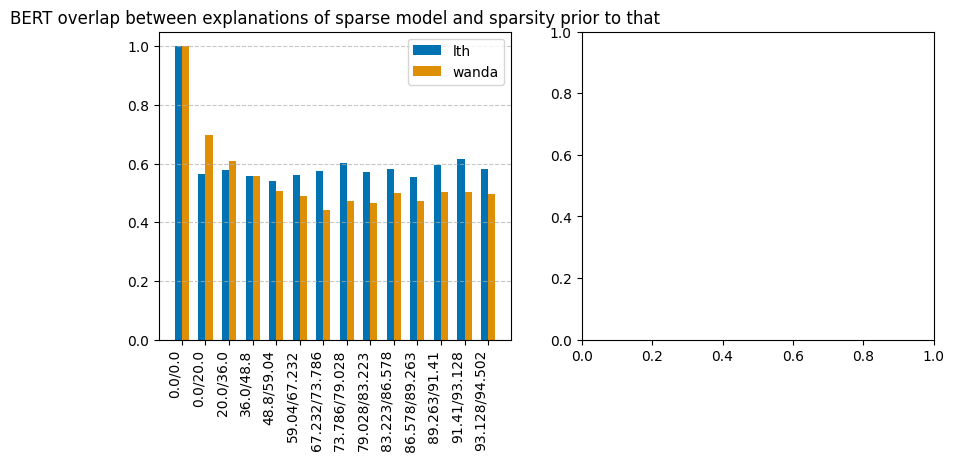

In [31]:
def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
        
        if float(sparsity) >= 82 and float(sparsity) <= 87:
            print(method, sparsity, len(explanations[float(sparsity)]))
    return explanations

def overlap(cur, prev):
    intersection = len(cur.intersection(prev))
    union = len(cur.union(prev))
    print(intersection, union, intersection/union)
    
    return intersection / union if union > 0 else 0


fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns
import numpy as np
model='BERT'
method='wanda'
filename='Run3'
global_concepts = get_concepts_across_cluster(model, method, filename)
x=get_sparsities(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())

bert_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
        
model='BERT'        
method='lottery_ticket'
filename='Run3'
global_concepts = get_concepts_across_cluster(model, method, filename)
x=get_sparsities(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bert_overlap_between_sparse_and_base_lth= []
print(sps)
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
     

x_axis=get_sparsities(model, method, filename)        
x = ["0.0/0.0"]+[f"{x_axis[j]}/{x_axis[j+1]}" for j in range(len(x_axis) - 1)]        
x_pos = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3

# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, bert_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[0].bar(x_pos + bar_width/2, bert_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[0].set_title('BERT overlap between explanations of sparse model and sparsity prior to that')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(x, rotation=90, ha='right')


model='BOWMAN'
method='wanda'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)
x_axis_w=get_sparsities(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
        
model='BOWMAN'        
method='lottery_ticket'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)   
base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_lth= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        

x_axis_l=get_sparsities(model, method, filename)        
x = ["0.0/0.0"]+[f"{x_axis_l[j]}/{x_axis_l[j+1]}" for j in range(len(x_axis_l) - 1)]        
x_pos_l = np.arange(len(x))  # Numeric positions for bars

   
x = ["0.0/0.0"]+[f"{x_axis_w[j]}/{x_axis_w[j+1]}" for j in range(len(x_axis_w) - 1)]        
x_pos_w = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3

# Plot grouped bars with offsets
axs[1].bar(x_pos_l - bar_width/2, bowman_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[1].bar(x_pos_w + bar_width/2, bowman_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[1].set_title('BERT overlap between explanations of sparse model and sparsity prior to that')
axs[1].legend()
axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[1].set_xticks(x_pos_w)
axs[1].set_xticklabels(x, rotation=90, ha='right')

# global overlap: % of concepts in prev that carry over to next

cur= 0.0, pre= 0 
cur= 19.987, pre= 0.0 
cur= 35.97, pre= 19.987 
cur= 48.796, pre= 35.97 
cur= 59.017, pre= 48.796 
cur= 67.22, pre= 59.017 
cur= 73.763, pre= 67.22 
cur= 79.004, pre= 73.763 
cur= 83.203, pre= 79.004 
cur= 86.556, pre= 83.203 
cur= 89.258, pre= 86.556 
cur= 91.406, pre= 89.258 
cur= 93.099, pre= 91.406 
cur= 94.499, pre= 93.099 
[0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
412 412 1.0
Comparing sparsity  20.0  with  0.0
298 529 0.5633270321361059
Comparing sparsity  36.0  with  20.0
314 537 0.5847299813780261
Comparing sparsity  48.8  with  36.0
319 534 0.5973782771535581
Comparing sparsity  59.04  with  48.8
307 519 0.5915221579961464
Comparing sparsity  67.232  with  59.04
296 537 0.5512104283054003
Comparing sparsity  73.786  with  67.232
311 540 0.575925925925926
Comparing sparsity  79.028  with  73.786
300 543 0.5524861878453039
Comparing sparsity  83.223  with  79.028
290 530 0.5471698113207547
Comparing s

"\naxs[1].bar(x_pos_l - bar_width/2, bowman_overlap_between_sparse_and_base_lth, \n           label='lth', color='#0173b2', width=bar_width)\n\naxs[1].bar(x_pos_w + bar_width/2, bowman_overlap_between_sparse_and_base_wanda, \n           label='wanda',color='#de8f05', width=bar_width)\n\naxs[1].set_title('                               BOWMAN overlap: % of concepts in prev that carry over to next')\naxs[1].legend()\naxs[1].grid(True, axis='y', linestyle='--', alpha=0.7)\naxs[1].set_xticks(x_pos_w)\naxs[1].set_xticklabels(x_w, rotation=90, ha='right')"

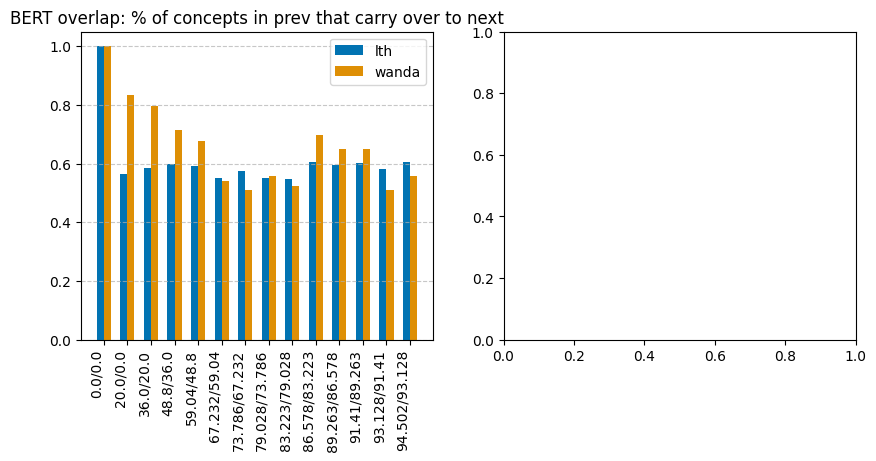

In [36]:
def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster{expl_clus}IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
    return explanations

def entailement(cur, prev):
    ct=0
    for i in prev:
        if i in cur:
            ct +=1
    return ct/len(prev)


fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns
import numpy as np
model='BERT'
method='wanda'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())

bert_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    
    if i-1 >= 0:
        
        print(f"cur= {sparsity}, pre= {sps[i-1]} ")
        bert_overlap_between_sparse_and_base_wanda.append(entailement(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        print(f"cur= {sparsity}, pre= 0 ")
        bert_overlap_between_sparse_and_base_wanda.append(entailement(global_concepts[sparsity],base_concepts))
        
model='BERT'        
method='lottery_ticket'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bert_overlap_between_sparse_and_base_lth= []
print(sps)
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
     

'''model='BOWMAN'
method='wanda'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
x_axis_w=get_sparsities(model, method, filename)       
x_w = ["0.0/0.0"]+[f"{x_axis_w[j]}/{x_axis_w[j-1]}" for j in range(1,len(x_axis_w))]        
x_pos_w = np.arange(len(x_w))  # Numeric positions for bars
 

model='BOWMAN'        
method='lottery_ticket'
filename='Run1'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_lth= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >=0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
'''

x_axis_l=get_sparsities(model, method, filename)       
x_l = ["0.0/0.0"]+[f"{x_axis_l[j]}/{x_axis_l[j-1]}" for j in range(1,len(x_axis_l))]        
x_pos_l = np.arange(len(x_l))  # Numeric positions for bars

bar_width = 0.3

# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, bert_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[0].bar(x_pos + bar_width/2, bert_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[0].set_title('BERT overlap: % of concepts in prev that carry over to next')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos_l)
axs[0].set_xticklabels(x_l, rotation=90, ha='right')


'''
axs[1].bar(x_pos_l - bar_width/2, bowman_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[1].bar(x_pos_w + bar_width/2, bowman_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[1].set_title('                               BOWMAN overlap: % of concepts in prev that carry over to next')
axs[1].legend()
axs[1].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[1].set_xticks(x_pos_w)
axs[1].set_xticklabels(x_w, rotation=90, ha='right')'''

In [ ]:
#every subseq iteration has rougly 60% of concepts preserved fromthe prev iter lthbert

#bowman 30% overlap between subseq pruning iters
bowman looses more concepts with pruning? or at least it doesnt preserve concepts as bert does cuz global overalp is very low
and locally after pruning % of concepts preserved drastially drops

the increase at 83/86 means those sparsities expl more sim cps than 79/83